In [3]:
def prim(graph, start):
    visited = []
    visited.append(start)

    result = []
    total = 0

    # keep going until all nodes are visited
    while len(visited) < len(graph):

        min_weight = 99999
        min_edge = None

        # check all visited nodes
        for node in visited:
            for neighbor, weight in graph[node]:

                # if neighbor not visited and weight is smaller
                if neighbor not in visited and weight < min_weight:
                    min_weight = weight
                    min_edge = (node, neighbor, weight)

        # add the cheapest edge we found
        visited.append(min_edge[1])
        result.append(min_edge)
        total = total + min_weight

    return result, total


# the graph
graph = {
    'a': [('b', 4), ('h', 8)],
    'b': [('a', 4), ('c', 8), ('h', 11)],
    'c': [('b', 8), ('d', 7), ('i', 2), ('f', 4)],
    'd': [('c', 7), ('e', 9), ('f', 14)],
    'e': [('d', 9), ('f', 10)],
    'f': [('c', 4), ('d', 14), ('e', 10), ('g', 2)],
    'g': [('f', 2), ('h', 1), ('i', 6)],
    'h': [('a', 8), ('b', 11), ('g', 1), ('i', 7)],
    'i': [('c', 2), ('g', 6), ('h', 7)]
}

# let user choose starting point
s = input("Enter starting vertex: ")
edges, total = prim(graph, s)

print("MST Edges:")
for e in edges:
    print(e[0], "--", e[1], "weight:", e[2])

print("Total cost:", total)

MST Edges:
c -- i weight: 2
c -- f weight: 4
f -- g weight: 2
g -- h weight: 1
c -- d weight: 7
c -- b weight: 8
b -- a weight: 4
d -- e weight: 9
Total cost: 37


In [2]:
# importing libraries
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque

In [3]:
# implementing topological sort 
def topological_sort(graph_dict):
    # calculate in-degree of every vertex
    in_degree = {u: 0 for u in graph_dict}
    for u in graph_dict:
        for v in graph_dict[u]:
            in_degree[v] = in_degree.get(v, 0) + 1
    # Add all vertices with in-degree 0 to a queue
    queue = deque([u for u in graph_dict if in_degree[u] == 0])
    topo_order = []
    while queue:
        u = queue.popleft()
        topo_order.append(u)
        # Iterate through neighbors
        for v in graph_dict.get(u, []):
            in_degree[v] -= 1
            # If in-degree becomes 0, add to queue
            if in_degree[v] == 0:
                queue.append(v)
    # Check for cycles
    if len(topo_order) != len(graph_dict):
        return "Graph contains a cycle; Topological Sort not possible."
    return topo_order

In [9]:
# Function to visualize graph and solve topological sort
def visualize_and_solve(adj_list, title, subplot_pos):
    # Create NetworkX graph
    G = nx.DiGraph(adj_list)
    # Plotting
    plt.subplot(2, 2, subplot_pos)
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', 
            node_size=2000, edge_color='gray', arrowsize=20, font_weight='bold')
    plt.title(title)
    # Apply Sorting
    order = topological_sort(adj_list)
    print(f"Topological Order for {title}: {order}")

Topological Order for Graph 1 : ['A', 'B', 'C', 'D', 'E']
Topological Order for Graph 2 : ['5', '4', '2', '0', '3', '1']
Topological Order for Graph 3 : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Topological Order for Graph 4 : ['0', '1', '2', '3', '4', '5', '6', '7']


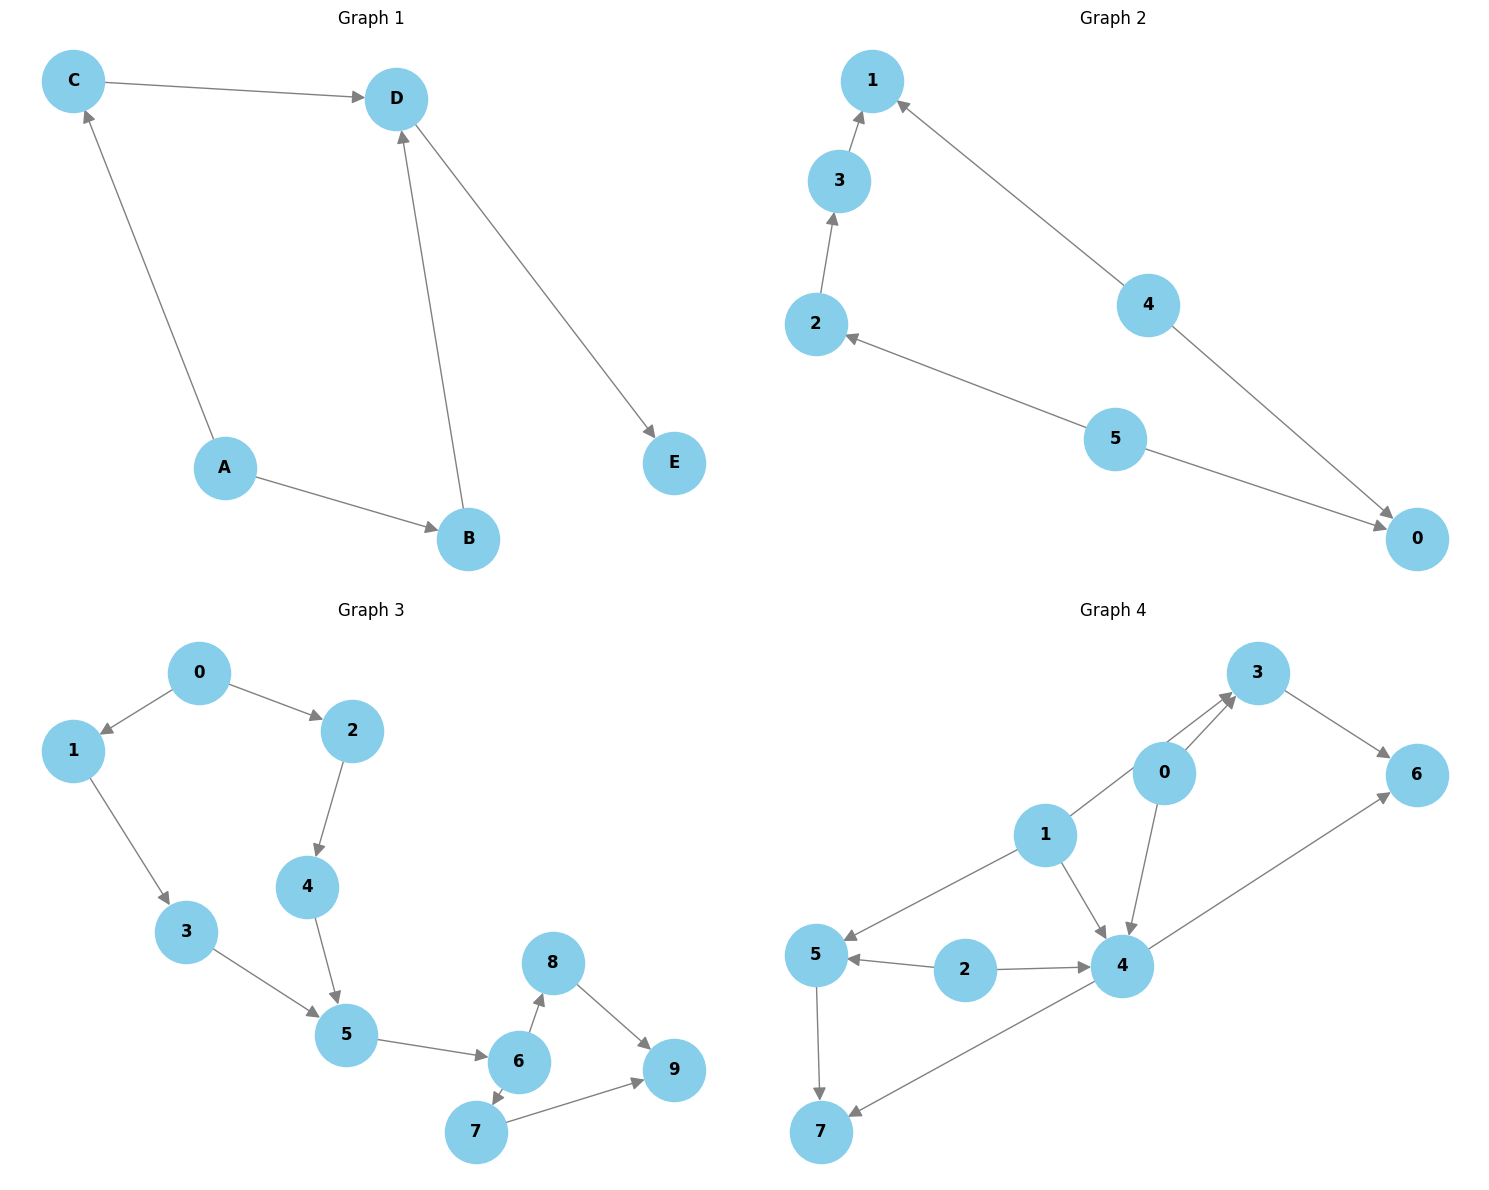

In [12]:
# some sample graphs
graph_1 = {
    'A': ['B', 'C'],
    'B': ['D'],
    'C': ['D'],
    'D': ['E'],
    'E': []}
graph_2 = {
    '5': ['2', '0'],
    '4': ['0', '1'],
    '2': ['3'],
    '3': ['1'],
    '0': [],
    '1': []}

graph_3 = {
    '0': ['1', '2'],
    '1': ['3'],
    '2': ['4'],
    '3': ['5'],
    '4': ['5'],
    '5': ['6'],
    '6': ['7', '8'],
    '7': ['9'],
    '8': ['9'],
    '9': []}

graph_4 = {
    '0': ['3', '4'],
    '1': ['3', '4', '5'],
    '2': ['4', '5'],
    '3': ['6'],
    '4': ['6', '7'],
    '5': ['7'],
    '6': [],
    '7': []}


plt.figure(figsize=(15, 12))
visualize_and_solve(graph_1, "Graph 1 ", 1)
visualize_and_solve(graph_2, "Graph 2 ", 2)
visualize_and_solve(graph_3, "Graph 3 ", 3)
visualize_and_solve(graph_4, "Graph 4 ", 4)
plt.tight_layout()
plt.show()